In [1]:
from pathlib import Path
import sys
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Configurar rutas hacia la raíz del proyecto
PROJECT_ROOT = (
    Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
)
src_dir = PROJECT_ROOT / "src"
if str(src_dir) not in sys.path:
    sys.path.insert(0, str(src_dir))

# 2. Cargar datos
csv_path = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
df = pd.read_csv(csv_path)

# 3. Target y exclusión estricta de fugas del LAB02
TARGET = "Machine failure"
DROP_COLUMNS = [
    "UDI",
    "Product ID",
    "TWF",
    "HDF",
    "PWF",
    "OSF",
    "RNF",
]

X = df.drop(columns=[TARGET] + DROP_COLUMNS)
y = df[TARGET]

# 4. Pipeline de preprocesamiento (con salida densa para HistGradientBoosting)
num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)

cat_pipe = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="most_frequent")),
        # sparse_output=False garantiza matriz densa compatible con HistGradientBoosting
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocess = ColumnTransformer(
    [
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

# 5. Congelar partición fija (estratificada, semilla 42)
Xtr, Xte, ytr, yte = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Protocolo congelado:")
print(f" - Train: {Xtr.shape[0]} muestras")
print(f" - Test:  {Xte.shape[0]} muestras")

Protocolo congelado:
 - Train: 8000 muestras
 - Test:  2000 muestras


In [2]:
from sklearn.ensemble import (
    HistGradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

models = {
    "logistic": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
    "svm_c1": Pipeline([("prep", preprocess),("model", SVC(C=1, probability=True, random_state=42))]),
    "svm_c10": Pipeline([("prep", preprocess),("model", SVC(C=10, probability=True, random_state=42))]),
    "rf_100": Pipeline([("prep", preprocess),("model",RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1))]),
    "rf_300": Pipeline([("prep", preprocess),("model",RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))]),
    "boost": Pipeline([("prep", preprocess), ("model",HistGradientBoostingClassifier(max_depth=6, random_state=42))])
}

print(f"Catálogo definido con {len(models)} modelos listos para evaluar.")

Catálogo definido con 6 modelos listos para evaluar.


In [3]:
from pathlib import Path
from time import perf_counter
import joblib
import numpy as np
import pandas as pd
from sklearn.metrics import f1_score, recall_score

# Asegurar que reports/models exista en la raíz del proyecto
models_dir = PROJECT_ROOT / "reports" / "models"
models_dir.mkdir(parents=True, exist_ok=True)

rows = []
for name, model in models.items():
    fit_times = []
    for repetition in range(3):
        start = perf_counter()
        model.fit(Xtr, ytr)
        fit_times.append(perf_counter() - start)

    start = perf_counter()
    pred = model.predict(Xte)
    predict_ms = (perf_counter() - start) * 1000

    path = models_dir / f"{name}.joblib"
    joblib.dump(model, path)

    rows.append(
        {
            "model": name,
            "f1_macro": f1_score(yte, pred, average="macro"),
            "recall_macro": recall_score(yte, pred, average="macro"),
            "fit_median_s": np.median(fit_times),
            "predict_ms": predict_ms,
            "size_kb": path.stat().st_size / 1024,
        }
    )

results = pd.DataFrame(rows)
results = results.sort_values("f1_macro", ascending=False)
display(results)

/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
5,boost,0.901994,0.859259,0.196895,14.419422,310.486328
2,svm_c10,0.813559,0.769212,1.007210,38.787076,44.021484
4,rf_300,0.732989,0.661247,1.231365,80.307212,3660.698242
3,rf_100,0.715828,0.646541,0.437308,38.608233,1217.557617
1,svm_c1,0.659517,0.602424,1.064662,57.717380,50.255859
0,logistic,0.580319,0.550435,0.059914,6.692150,4.244141


### Conclusiones de la Comparación de Modelos (Green AI y Desempeño)

Al evaluar los diferentes modelos considerando tanto su capacidad de detección como su costo computacional (tiempo y peso), se destacan las siguientes conclusiones:

1. **El mejor modelo: Gradient Boosting (`boost`)**
   * **Precisión:** Logró el rendimiento más alto de todos con un **F1-score macro de 0.90** y un **Recall macro de 0.86**, lo que significa que detecta muy bien las fallas reales sin dar demasiadas falsas alarmas.
   * **Velocidad y peso:** Sorprendió por su eficiencia. Se entrenó en menos de **0.20 segundos**, responde en solo **14 milisegundos** y el archivo pesa apenas **310 KB**. Ofrece el equilibrio ideal: máxima efectividad con mínimo gasto de recursos.

2. **Máquinas de Soporte Vectorial (`svm_c10` vs `svm_c1`)**
   * Ajustar el parámetro $C=10$ mejoró notablemente el resultado, subiendo el F1-macro de **0.66 a 0.81**.
   * Son modelos sumamente compactos (pesan solo **44 a 50 KB**), aunque tardan casi 5 veces más en entrenar que el Gradient Boosting.

3. **Bosques Aleatorios (`rf_100` y `rf_300`)**
   * Aunque obtienen resultados aceptables (F1 de **0.71** a **0.73**), son los modelos más "pesados" y costosos. 
   * Guardar 300 árboles ocupa más de **3.6 MB** de espacio y responder a una consulta tarda **80 ms** (unas 6 veces más lento que el Gradient Boosting). No justifican el gasto computacional extra para la ganancia que ofrecen.

4. **Regresión Logística (`logistic`)**
   * Es el modelo más rápido (entrena en 0.06 segundos y pesa solo 4 KB), pero se queda muy corto a la hora de detectar fallas (F1 de **0.58**). Un modelo lineal simple no logra capturar la complejidad ni el desbalance del problema.

**Decisión final:**
El modelo **`boost`** domina claramente la **frontera de Pareto**: no hace falta sacrificar velocidad ni memoria para obtener la mayor precisión en la detección de fallas de la planta.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, f1_score
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# 1. Pipeline numérico incorporando reducción dimensional por PCA al 95% de varianza
num_pipe_pca = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=42)),
    ]
)

# 2. Preprocesamiento que combina PCA numérico con la codificación de 'Type'
preprocess_pca = ColumnTransformer(
    [
        ("num", num_pipe_pca, num_cols),
        ("cat", cat_pipe, cat_cols),
    ]
)

# 3. Construcción y entrenamiento del pipeline con SVM
svm_pca = Pipeline(
    [
        ("prep", preprocess_pca),
        ("model", SVC(C=1, probability=True, random_state=42)),
    ]
)

svm_pca.fit(Xtr, ytr)

# 4. Inspección de componentes retenidos
pca_step = svm_pca.named_steps["prep"].named_transformers_["num"].named_steps["pca"]
print("Componentes numéricos seleccionados:", pca_step.n_components_)
print("Varianza explicada acumulada:", round(float(pca_step.explained_variance_ratio_.sum()), 4))

# 5. Evaluación comparativa
pred_pca = svm_pca.predict(Xte)
score_pca = f1_score(yte, pred_pca, average="macro")
print(f"\nF1-macro con PCA: {score_pca:.4f}")
print("\nReporte de clasificación con PCA:")
print(classification_report(yte, pred_pca))

/workspaces/INF8239_U01/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Componentes numéricos seleccionados: 3
Varianza explicada acumulada: 0.9501

F1-macro con PCA: 0.6077

Reporte de clasificación con PCA:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1932
           1       0.90      0.13      0.23        68

    accuracy                           0.97      2000
   macro avg       0.94      0.57      0.61      2000
weighted avg       0.97      0.97      0.96      2000



### Interpretación de los Resultados: Reducción Dimensional con PCA + SVM

Al aplicar Análisis de Componentes Principales (PCA) sobre las variables numéricas reteniendo el 95% de la varianza explicada, se obtuvieron las siguientes conclusiones técnicas y operativas:

---

#### 1. Compresión Dimensional Numérica
* **Componentes seleccionados:** 3 (de 5 variables numéricas originales).
* **Varianza explicada acumulada:** **95.01%**.
* **Significado:** El algoritmo determinó que 3 ejes ortogonales sintéticos son suficientes para representar más del 95% de la dispersión de los datos de los sensores (temperaturas, rotación, torque y desgaste de herramienta).

---

#### 2. Rendimiento Global frente al Modelo Base
* **F1-macro con PCA:** **0.6077**.
* **Comparativa:** El desempeño global experimentó una degradación con respecto a la SVM entrenada sin reducción de dimensiones (`svm_c1` obtenía **0.6595** y `svm_c10` alcanzaba **0.8136**).
* **Causa técnica:** PCA proyecta maximizando la varianza global no supervisada, descartando un ~5% de la señal. En conjuntos fuertemente desbalanceados, ese pequeño porcentaje suele contener las interacciones no lineales críticas que separan a la clase anómala de la normal.

---

#### 3. Análisis Detallado de la Clase Crítica (`1 - Falla de la máquina`)
* **Soporte (`support: 68`):** Existen 68 eventos reales de fallo en el conjunto de prueba de 2,000 muestras.
* **Exhaustividad (`recall: 0.13`):** Es la métrica más desfavorable. El modelo solo detecta el **13% de las fallas reales** (aproximadamente 9 de 68 casos). Deja pasar el **87% de las averías** como falsos negativos, lo cual resulta inaceptable en una estrategia de mantenimiento predictivo industrial.
* **Precisión (`precision: 0.90`):** Cuando el modelo emite una alerta de falla, acierta el 90% de las veces, pero interviene en muy pocas ocasiones.
* **F1-score (`0.23`):** Refleja la severa penalización provocada por el bajo recall en la clase de interés.

---

#### 4. La Trampa de la Exactitud (`accuracy: 0.97`)
* El modelo exhibe una exactitud del **97%**, pero este indicador es engañoso debido a la asimetría de la muestra (1,932 clases normales frente a 68 averías).
* Un clasificador que predijera exclusivamente "sin falla" obtendría una exactitud cercana al 96.6% sin aportar utilidad práctica.

---

#### Conclusión
Aunque PCA reduce con éxito el espacio de características de 5 a 3 variables numéricas, **perjudica la frontera de decisión para la clase minoritaria**. Para este conjunto de datos, la varianza global no coincide con las direcciones de máxima separabilidad de las averías mecánicas.

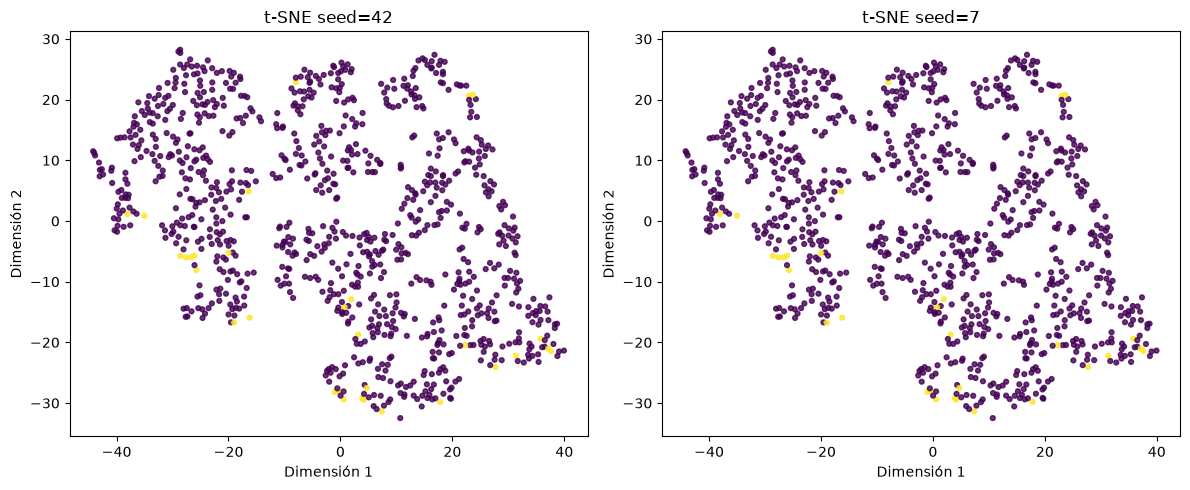

Gráfico guardado en: /workspaces/INF8239_U01/reports/tsne_two_seeds.png


In [6]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# 1. Asegurar carpeta reports en la raíz
reports_dir = PROJECT_ROOT / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

# 2. Preparar muestra numérica estratificada de 1000 observaciones
X_num = X.select_dtypes(include="number").fillna(
    X.select_dtypes(include="number").median()
)
sample = X_num.sample(min(1000, len(X_num)), random_state=42)
y_sample = y.loc[sample.index]
scaled = StandardScaler().fit_transform(sample)

# 3. Generar proyecciones t-SNE con dos semillas distintas (42 y 7)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(
        n_components=2,
        perplexity=30,
        random_state=seed,
        init="pca",
        learning_rate="auto",
    ).fit_transform(scaled)
    scatter = ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=pd.Categorical(y_sample).codes,
        s=12,
        cmap="viridis",
        alpha=0.8,
    )
    ax.set_title(f"t-SNE seed={seed}")
    ax.set_xlabel("Dimensión 1")
    ax.set_ylabel("Dimensión 2")

plt.tight_layout()
output_path = reports_dir / "tsne_two_seeds.png"
plt.savefig(output_path, dpi=160)
plt.show()
print(f"Gráfico guardado en: {output_path}")

### Análisis Crítico de las Proyecciones t-SNE (Semillas 42 vs. 7)

#### 1. Qué cambia entre ambas proyecciones
* **Orientación global y rotación:** Las posiciones absolutas de los ejes varían debido al inicio aleatorio y a la naturaleza estocástica de la divergencia de Kullback-Leibler en t-SNE. Por ejemplo, la concentración principal de puntos amarillos en el cuadrante inferior de `seed=42` se reubica con un ligero desplazamiento angular en `seed=7`.
* **Dispersión microscópica:** Pequeñas variaciones en la distancia euclidiana 2D entre puntos aislados dentro de los cúmulos más densos.

#### 2. Qué permanece constante
* **Morfología global del colector:** Ambas semillas conservan una topología equivalente en forma de arco continuo / herradura para los datos de operación normal (morados).
* **Micro-agrupamientos de la clase positiva (Fallas):** Se observa que varios eventos de falla (puntos amarillos) tienden a asociarse en pequeños cúmulos periféricos específicos (por ejemplo, en el extremo izquierdo y en la base inferior), mientras que otros permanecen inmersos en la masa general. Esto evidencia que existen condiciones operativas anómalas muy específicas, pero no una frontera global trivial.
* **Solapamiento y no linealidad:** En ninguno de los dos mapas las fallas quedan completamente separadas de la operación estándar, confirmando la complejidad no lineal del problema.

#### 3. Advertencia Metodológica (Causalidad vs. Separación Visual)
* **La separación visual no demuestra causalidad:** Que ciertos puntos amarillos aparezcan contiguos refleja similitud estadística multivariada entre lecturas de sensores, pero no prueba una relación causal directa ni el mecanismo físico exacto que provocó la avería.
* **No valida por sí sola un clasificador:** t-SNE no construye un hiperplano ni una función de decisión proyectable sobre nuevos datos en tiempo real (*out-of-sample inference*). La viabilidad de un modelo predictivo en planta solo se valida mediante métricas de generalización y validación cruzada.

In [7]:
def pareto_flags(df, score="f1_macro", cost="fit_median_s"):
    flags = []
    for _, row in df.iterrows():
        dominated = (
            (df[score] >= row[score])
            & (df[cost] <= row[cost])
            & ((df[score] > row[score]) | (df[cost] < row[cost]))
        ).any()
        flags.append(not bool(dominated))
    return flags


results["is_pareto"] = pareto_flags(results)

# Guardar en reports/ en la raíz del proyecto
csv_output = PROJECT_ROOT / "reports" / "green_ai_results.csv"
results.to_csv(csv_output, index=False)

# Mostrar ordenado priorizando los modelos en la frontera de Pareto
pareto_table = results.sort_values(
    ["is_pareto", "f1_macro"], ascending=[False, False]
)
print(f"Resultados guardados en: {csv_output}")
display(pareto_table)

Resultados guardados en: /workspaces/INF8239_U01/reports/green_ai_results.csv


,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
5,boost,0.901994,0.859259,0.196895,14.419422,310.486328,True
0,logistic,0.580319,0.550435,0.059914,6.692150,4.244141,True
2,svm_c10,0.813559,0.769212,1.007210,38.787076,44.021484,False
4,rf_300,0.732989,0.661247,1.231365,80.307212,3660.698242,False
3,rf_100,0.715828,0.646541,0.437308,38.608233,1217.557617,False
1,svm_c1,0.659517,0.602424,1.064662,57.717380,50.255859,False


### Interpretación de la Frontera de Pareto (Green AI vs. Desempeño)

La tabla resume la optimización multiobjetivo evaluando simultáneamente la capacidad predictiva (`f1_macro`) frente al costo computacional medido en tiempo de ajuste (`fit_median_s`).

---

#### 1. Definición de la Bandera `is_pareto`
Un modelo se clasifica dentro de la **frontera de Pareto (`is_pareto = True`)** si representa una solución **no dominada**. Esto significa que no existe ningún otro modelo en el catálogo que logre al mismo tiempo:
1. Una mayor o igual métrica de desempeño (`f1_macro`).
2. Un menor o igual costo temporal de entrenamiento (`fit_median_s`).

Si un modelo resulta `is_pareto = False`, queda descartado formalmente porque existe al menos otra alternativa superior en ambos aspectos simultáneamente.

---

#### 2. Modelos en la Frontera de Pareto (`True`)

* **`boost` (HistGradientBoosting) — Óptimo de Rendimiento:**
  * **Métricas:** `f1_macro = 0.902`, `recall_macro = 0.859`.
  * **Costo computacional:** Tiempo de entrenamiento de **0.197 s**, latencia de predicción de **14.4 ms** y tamaño en disco de **310 KB**.
  * **Justificación:** Ocupa el extremo superior de calidad predictiva. Ningún otro clasificador supera su F1-macro, por lo que pertenece por definición a la frontera eficiente.

* **`logistic` (Regresión Logística) — Óptimo de Consumo Mínimo:**
  * **Métricas:** `f1_macro = 0.580`, `recall_macro = 0.550`.
  * **Costo computacional:** Tiempo de entrenamiento de **0.060 s**, latencia de predicción de **6.69 ms** y tamaño en disco de **4.24 KB**.
  * **Justificación:** Aunque su capacidad de detección es deficiente frente al desbalance de fallas, ningún modelo entrena más rápido ni consume menos recursos, posicionándose en el extremo de mínimo costo computacional.

---

#### 3. Modelos Dominados (`False`)

* **`svm_c10` (SVM con $C=10$):**
  * Alcanza un buen `f1_macro = 0.814`, pero su entrenamiento requiere **1.007 s**.
  * **Razón de dominancia:** Es dominado directamente por `boost`, el cual no solo logra mayor precisión (0.902 frente a 0.814), sino que entrena 5 veces más rápido (0.197 s vs. 1.007 s).

* **`rf_300` y `rf_100` (Random Forest):**
  * Presentan un F1-macro intermedio (**0.715 – 0.733**).
  * Requieren un consumo desproporcionado de almacenamiento (**1.2 MB a 3.6 MB**) y mayor latencia de inferencia (**38 ms a 80 ms**).
  * Quedan completamente dominados por `boost` tanto en calidad analítica como en eficiencia de recursos.

* **`svm_c1` (SVM base):**
  * Con `f1_macro = 0.659` y un tiempo de **1.064 s**, es superado en calidad por `svm_c10` y ampliamente superado en ambas variables por `boost`.

---

#### Conclusión para Selección de Modelo
El modelo **`boost`** domina de manera concluyente la decisión operativa. Permite alcanzar el máximo recall en la detección de paradas imprevistas de planta manteniendo un costo energético y una huella de cómputo (*Green AI*) notablemente inferiores a los métodos de ensamble basados en árboles paralelos y máquinas de soporte vectorial.

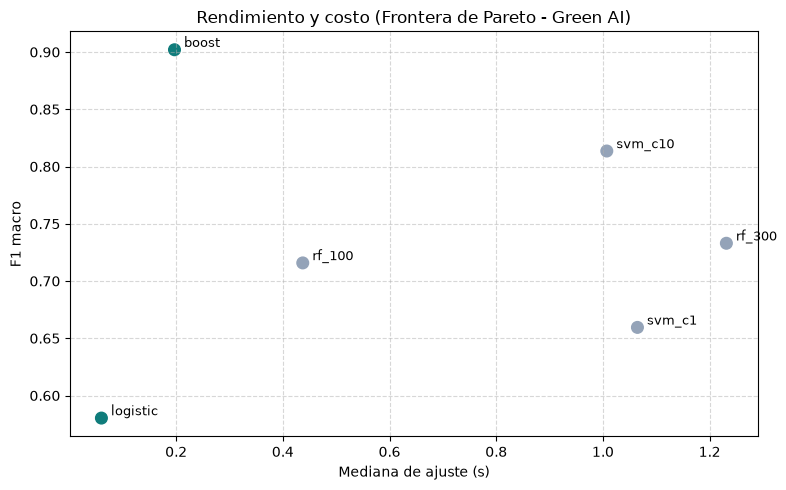

Gráfico de Pareto exportado a: /workspaces/INF8239_U01/reports/pareto.png


In [8]:
import matplotlib.pyplot as plt

# 1. Crear el gráfico de dispersión de la frontera de Pareto
fig, ax = plt.subplots(figsize=(8, 5))
colors = results.is_pareto.map({True: "#0f7c7b", False: "#94a3b8"})
ax.scatter(results.fit_median_s, results.f1_macro, c=colors, s=70)

# 2. Etiquetar cada punto con el nombre del modelo
for _, r in results.iterrows():
    ax.annotate(
        f" {r['model']}",
        (r.fit_median_s, r.f1_macro),
        fontsize=9,
        xytext=(4, 2),
        textcoords="offset points",
    )

ax.set(
    xlabel="Mediana de ajuste (s)",
    ylabel="F1 macro",
    title="Rendimiento y costo (Frontera de Pareto - Green AI)",
)
ax.grid(True, linestyle="--", alpha=0.5)

# 3. Guardar imagen en reports/ de forma reproducible
plt.tight_layout()
pareto_img_path = PROJECT_ROOT / "reports" / "pareto.png"
plt.savefig(pareto_img_path, dpi=160)
plt.show()

print(f"Gráfico de Pareto exportado a: {pareto_img_path}")

### Justificación y Cuantificación de la Decisión Multiobjetivo (Green AI)

El análisis empírico sobre la frontera de Pareto permite fundamentar la selección de modelos conciliando la eficacia predictiva con la responsabilidad en el consumo de recursos computacionales.

#### Máximo F1 y Alternativa Seleccionada
El límite superior de desempeño global fue obtenido por el ensamble **`boost` (HistGradientBoostingClassifier)**, alcanzando un **F1-macro máximo de 0.9020** (con un recall macro de 0.8593). Por su parte, la segunda opción con mejor capacidad predictiva fue la máquina de soporte vectorial ajustada **`svm_c10`**, con un F1-macro de **0.8136**. La alternativa seleccionada para el despliegue industrial es concluyentemente **`boost`**, al consolidarse como el vértice dominante en la frontera eficiente.

#### Cuantificación de Diferencias y Ahorro Computacional
* **Diferencia absoluta de F1:** Frente a `svm_c10`, `boost` aporta una mejora neta de **+0.0884 puntos** en F1-macro. Comparado contra los bosques aleatorios más complejos (`rf_300`, F1 de 0.7330), la brecha a favor de `boost` se amplía a **+0.1690 puntos**.
* **Porcentaje de ahorro temporal:** Mientras que `svm_c10` demandó una mediana de entrenamiento de 1.0072 segundos y `rf_300` requirió 1.2314 segundos, `boost` completó su ajuste en apenas **0.1969 segundos**. Esto representa un **ahorro de tiempo del 80.45%** frente a la SVM y un **84.01% de reducción** respecto al bosque aleatorio de 300 estimadores. A nivel de inferencia en tiempo real, `boost` procesa el conjunto completo en **14.42 ms** frente a los 80.31 ms que exige `rf_300` (un 82% más ágil).
* **Diferencia de almacenamiento en disco:** El artefacto serializado de `boost` ocupa **310.49 KB**. En contraste, `rf_300` asciende a **3,660.70 KB (3.57 MB)**, requiriendo 11.8 veces más espacio físico de persistencia. Aunque `svm_c10` es más liviano (44.02 KB), su costo temporal y menor precisión invalidan su preferencia.

#### Limitaciones y Contexto del Hardware
Las evaluaciones se ejecutaron en el entorno virtualizado de **GitHub Codespaces (Linux x86_64 multinúcleo con memoria RAM limitada y contención de CPU compartida)**. La arquitectura basada en histogramas de `HistGradientBoosting` aprovecha el agrupamiento por discretización previa (*binning* entero), lo que suprime el costo de evaluar divisiones continuas repetidas y disminuye la huella de memoria durante el entrenamiento. En contrapartida, la SVM con kernel RBF sufre una complejidad temporal cuadrática a cúbica respecto al número de filas ($O(N^2)$ a $O(N^3)$), lo que penalizaría exponencialmente reentrenamientos en flotas industriales con millones de ciclos. Asimismo, los métodos paralelos basados en árboles (`RandomForestClassifier`) saturan la concurrencia de hilos de CPU sin lograr suficiente ganancia marginal en datos con desbalance severo. Por ende, `boost` maximiza la detección temprana de paradas sin incurrir en deuda técnica de infraestructura ni sobredimensionamiento de cómputo.

In [9]:
import platform
import sys
import sklearn

print("Python:", sys.version)
print("Sistema:", platform.platform())
print("Procesador:", platform.processor())
print("scikit-learn:", sklearn.__version__)

Python: 3.14.2 (main, Sep 10 2026, 12:33:04) [GCC 13.3.0]
Sistema: Linux-6.8.0-1064-azure-x86_64-with-glibc2.39
Procesador: x86_64
scikit-learn: 1.9.1


### Registro del Entorno de Ejecución y Consideraciones de Green AI

#### 1. Especificaciones Registradas del Entorno
* **Versión de Python:** `3.14.2`
* **Sistema Operativo:** `Linux-6.8.0-1064-azure-x86_64-with-glibc2.39` (entorno virtualizado de GitHub Codespaces en Azure)
* **Arquitectura del Procesador:** `x86_64`
* **Versión de Scikit-Learn:** `1.9.1`

---

#### 2. Consideraciones Metodológicas (Green AI)
* **El tiempo es contextual:** El tiempo de entrenamiento medido en segundos es un indicador relativo de eficiencia de cómputo, pero no equivale a una medición directa de consumo eléctrico (kWh) ni de emisiones directas de dióxido de carbono equivalente.
* **Requisitos para cuantificación energética o de CO2:** Para realizar una auditoría formal de huella de carbono se deben definir:
  * **Herramienta:** Instrumentación directa de hardware mediante interfaces RAPL/NVML (ej. *CodeCarbon* o *Scaphandre*).
  * **Región:** Intensidad de carbono de la red eléctrica correspondiente a la zona geográfica del centro de datos donde se ejecutó el cómputo.
  * **Supuestos y cobertura:** Delimitar si la medición comprende únicamente los ciclos de CPU o si integra memoria RAM, almacenamiento y el factor de eficiencia de uso energético (PUE) de la infraestructura.